# 💳 Project 3: Loan Eligibility Prediction

**Goal:** Predict whether a loan application will be **Approved** or **Not Approved**  
**Algorithms:** Logistic Regression · Decision Tree · Random Forest  
**Tools:** Python · Pandas · Scikit-learn · Matplotlib · Seaborn  

---


In [18]:
# ── Install / Import Libraries ────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay,
                              roc_curve, auc)

sns.set_theme(style="whitegrid", palette="muted")
print("✅ Libraries loaded successfully!")


✅ Libraries loaded successfully!


## 1. Load Dataset

In [31]:
import pandas as pd

from google.colab import files
uploaded = files.upload()

# Load your local dataset
df = pd.read_csv("train.csv")

print(f"Dataset Shape: {df.shape}")
print(df.head())

Saving train.csv to train.csv
Dataset Shape: (614, 13)
    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1          

In [32]:
print("Columns & Data Types:")
print(df.dtypes)
print("\nTarget value counts:")
print(df['Loan_Status'].value_counts())


Columns & Data Types:
Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object

Target value counts:
Loan_Status
Y    422
N    192
Name: count, dtype: int64


## 2. Exploratory Data Analysis

                  Missing Count  Missing %
Gender                       13       2.12
Married                       3       0.49
Dependents                   15       2.44
Self_Employed                32       5.21
LoanAmount                   22       3.58
Loan_Amount_Term             14       2.28
Credit_History               50       8.14


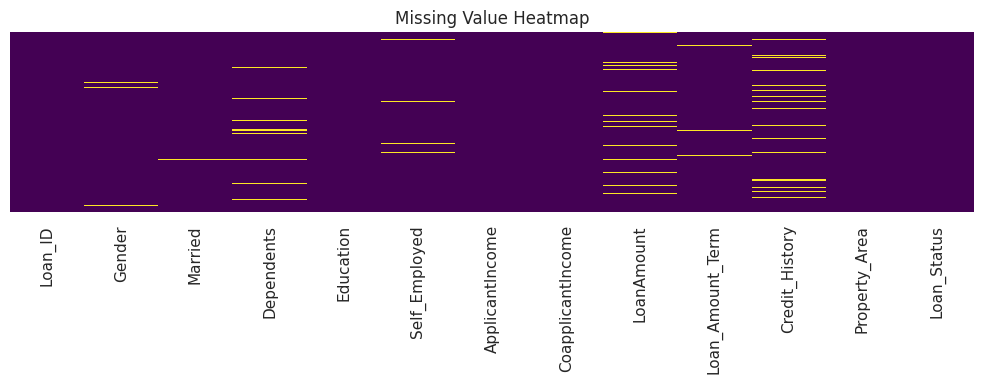

In [33]:
# ── Missing values ────────────────────────────────────────────────────────────
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %'    : (df.isnull().sum() / len(df) * 100).round(2)
})
print(missing[missing['Missing Count'] > 0])

plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title("Missing Value Heatmap")
plt.tight_layout()
plt.show()


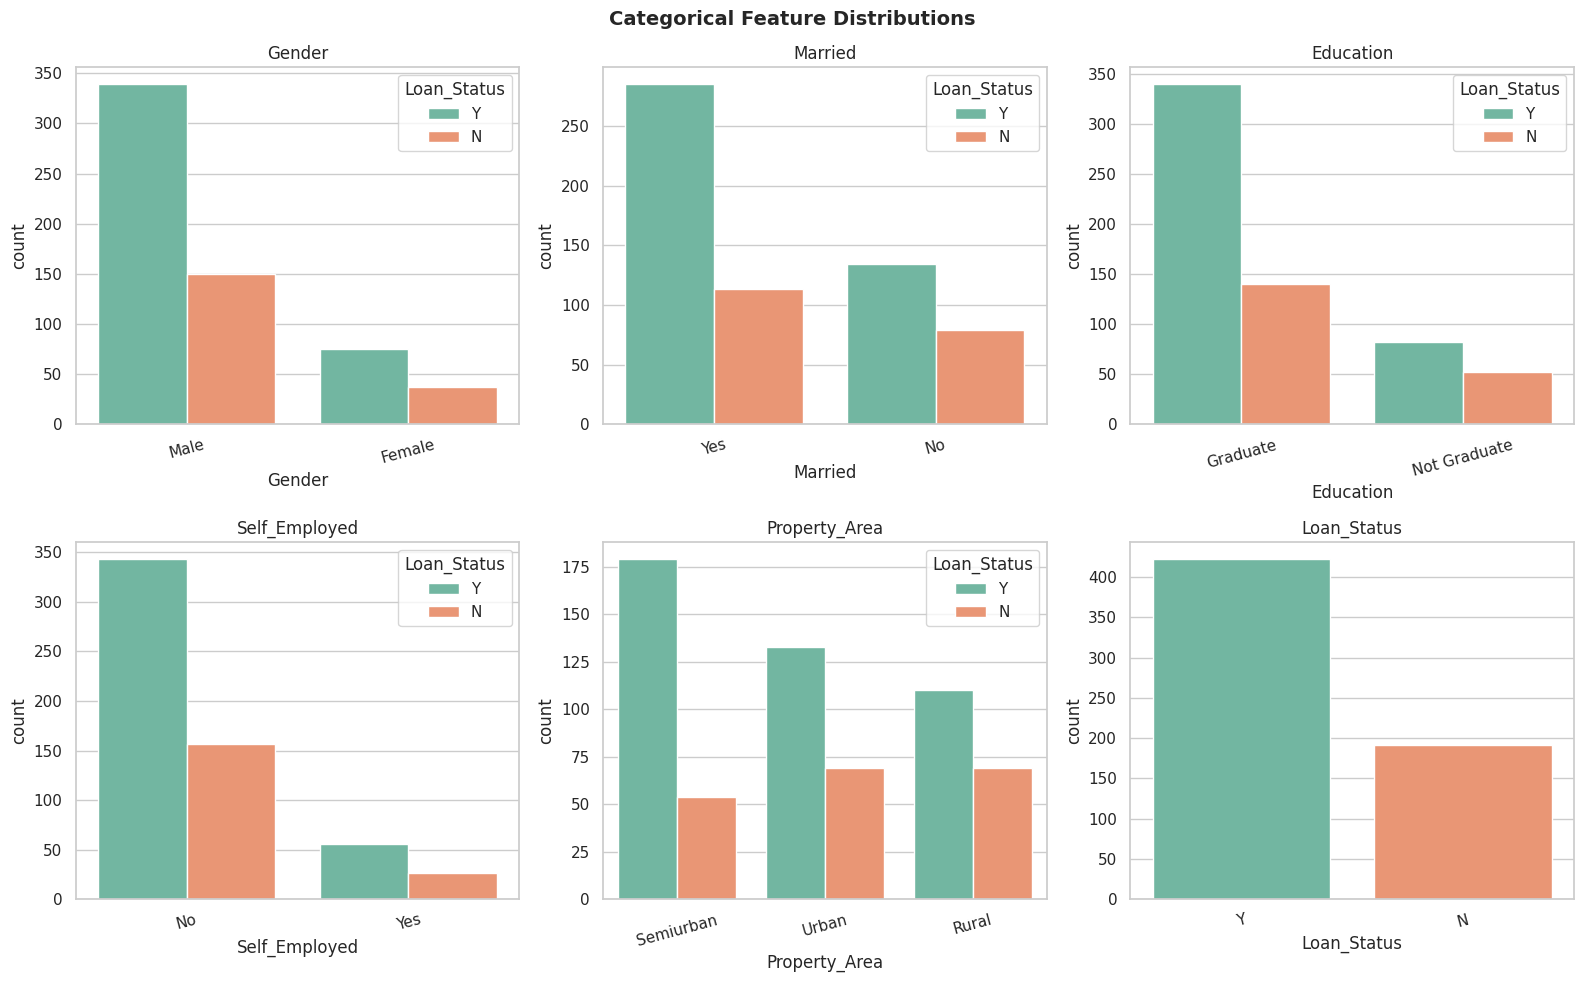

In [34]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Categorical Feature Distributions", fontsize=14, fontweight='bold')

cat_cols = ['Gender', 'Married', 'Education', 'Self_Employed',
            'Property_Area', 'Loan_Status']

for ax, col in zip(axes.flatten(), cat_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, hue='Loan_Status',
                  order=order, ax=ax, palette='Set2')
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()


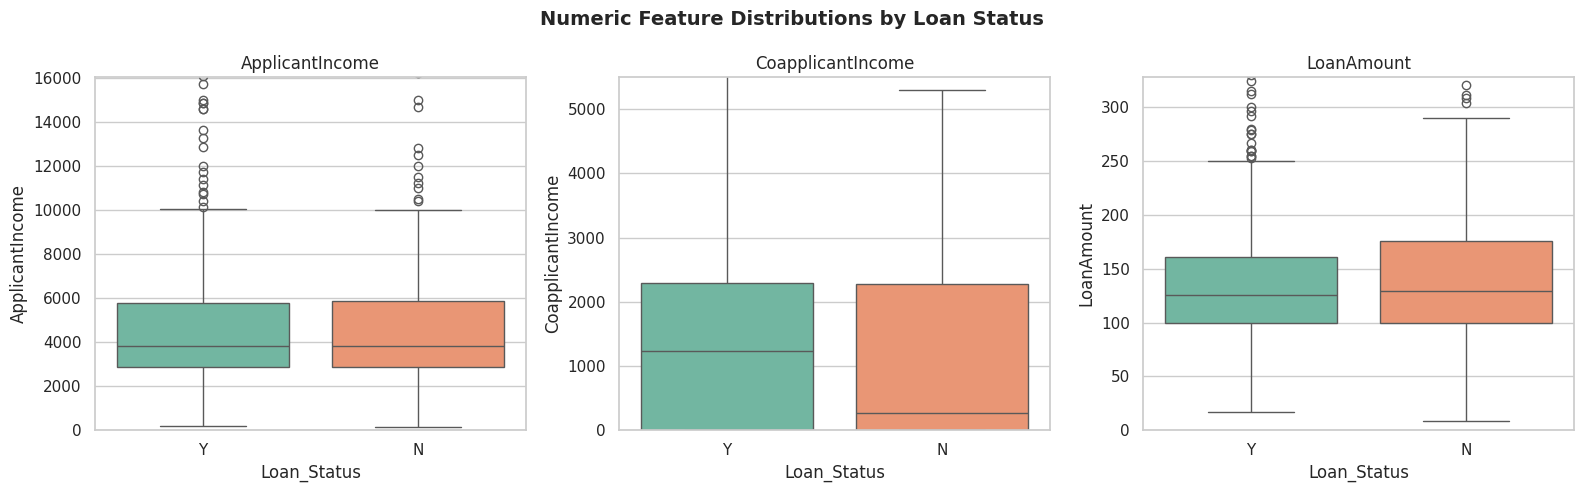

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Numeric Feature Distributions by Loan Status",
             fontsize=14, fontweight='bold')

for ax, col in zip(axes, ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']):
    sns.boxplot(data=df, x='Loan_Status', y=col, ax=ax, palette='Set2')
    ax.set_title(col)
    # cap y-axis to reduce distortion from extreme outliers
    ax.set_ylim(0, df[col].quantile(0.95) * 1.1)

plt.tight_layout()
plt.show()


## 3. Data Cleaning & Preprocessing

In [36]:
df_clean = df.copy()

# ── Drop Loan_ID (not a feature) ─────────────────────────────────────────────
df_clean.drop(columns=['Loan_ID'], inplace=True)

# ── Fill missing values ───────────────────────────────────────────────────────
for col in df_clean.select_dtypes(include=['object']).columns:
    df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)

for col in df_clean.select_dtypes(include=[np.number]).columns:
    df_clean[col].fillna(df_clean[col].median(), inplace=True)

print("Missing values after cleaning:", df_clean.isnull().sum().sum())

# ── Feature Engineering ───────────────────────────────────────────────────────
df_clean['TotalIncome']      = df_clean['ApplicantIncome'] + df_clean['CoapplicantIncome']
df_clean['LoanAmountTerm']   = df_clean['LoanAmount'] / (df_clean['Loan_Amount_Term'] + 1)
df_clean['IncomePerLoan']    = df_clean['TotalIncome'] / (df_clean['LoanAmount'] + 1)

print("\nNew features added: TotalIncome, LoanAmountTerm, IncomePerLoan")
df_clean.head()


Missing values after cleaning: 0

New features added: TotalIncome, LoanAmountTerm, IncomePerLoan


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome,LoanAmountTerm,IncomePerLoan
0,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y,5849.0,0.354571,45.341085
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N,6091.0,0.354571,47.217054
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y,3000.0,0.182825,44.776119
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y,4941.0,0.332410,40.834711
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y,6000.0,0.390582,42.253521


In [37]:
# ── Encode Categorical Variables ──────────────────────────────────────────────
le = LabelEncoder()
for col in df_clean.select_dtypes(include=['object']).columns:
    df_clean[col] = le.fit_transform(df_clean[col])

print("All columns after encoding:")
print(df_clean.dtypes)


All columns after encoding:
Gender                 int64
Married                int64
Dependents             int64
Education              int64
Self_Employed          int64
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area          int64
Loan_Status            int64
TotalIncome          float64
LoanAmountTerm       float64
IncomePerLoan        float64
dtype: object


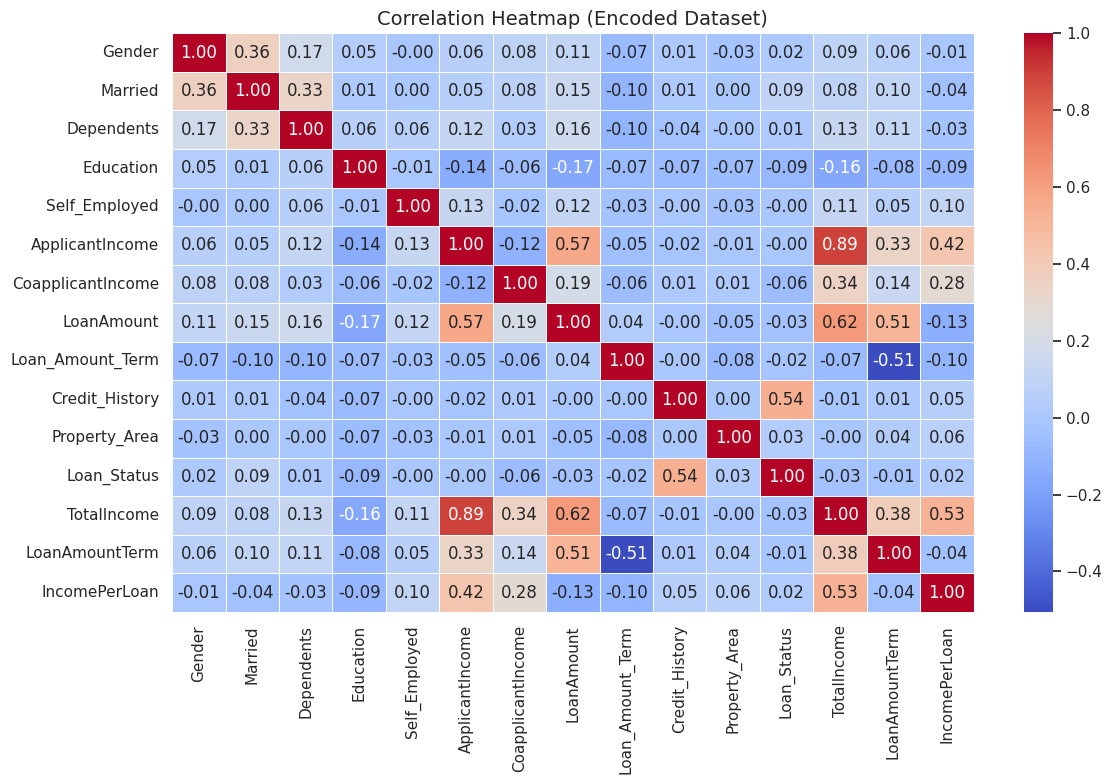

In [38]:
# ── Correlation Heatmap ───────────────────────────────────────────────────────
plt.figure(figsize=(12, 8))
sns.heatmap(df_clean.corr(), annot=True, fmt=".2f",
            cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap (Encoded Dataset)", fontsize=14)
plt.tight_layout()
plt.show()


## 4. Train / Test Split & Scaling

In [39]:
X = df_clean.drop(columns=['Loan_Status'])
y = df_clean['Loan_Status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train: {len(X_train)} samples  |  Test: {len(X_test)} samples")
print(f"Features: {list(X.columns)}")


Train: 491 samples  |  Test: 123 samples
Features: ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'TotalIncome', 'LoanAmountTerm', 'IncomePerLoan']


## 5. Train & Compare Models

In [40]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree'      : DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}
for name, clf in models.items():
    clf.fit(X_train_sc, y_train)
    y_pred = clf.predict(X_test_sc)
    acc    = accuracy_score(y_test, y_pred)
    cv     = cross_val_score(clf, X_train_sc, y_train, cv=5, scoring='accuracy').mean()
    results[name] = {'Model': clf, 'Test Accuracy': acc, 'CV Accuracy': cv,
                     'Predictions': y_pred}
    print(f"{name:25s} → Test Acc: {acc:.4f}  |  CV Acc: {cv:.4f}")


Logistic Regression       → Test Acc: 0.8618  |  CV Acc: 0.7882
Decision Tree             → Test Acc: 0.8049  |  CV Acc: 0.7882
Random Forest             → Test Acc: 0.8537  |  CV Acc: 0.7617


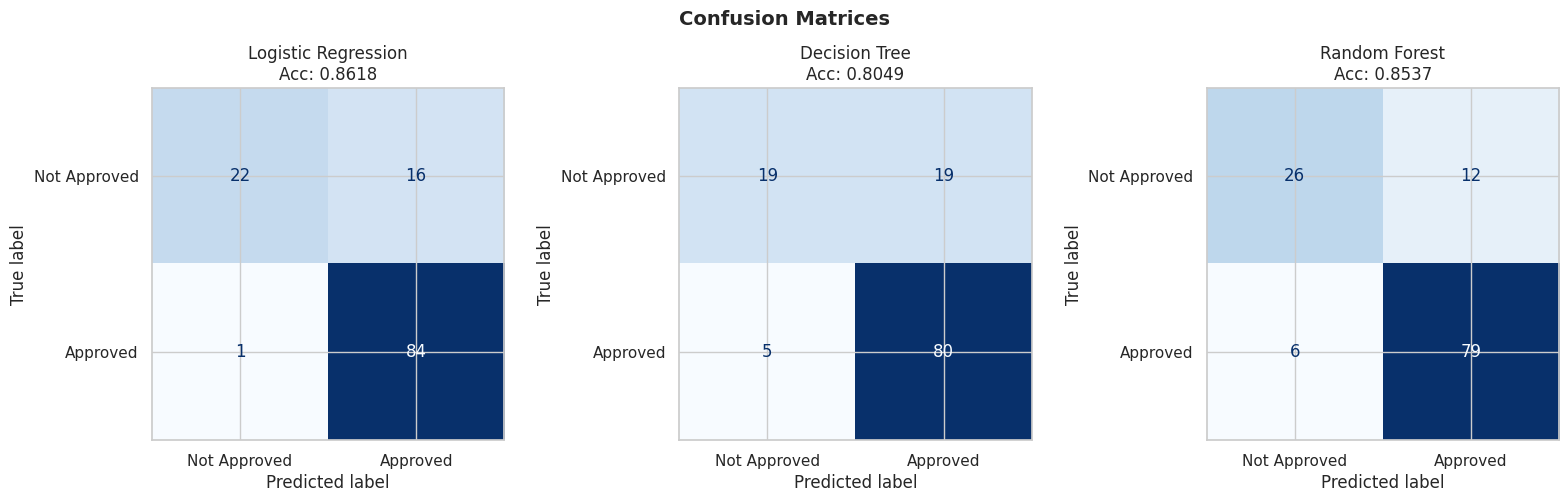

In [41]:
# ── Confusion Matrices ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Confusion Matrices", fontsize=14, fontweight='bold')

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['Predictions'])
    ConfusionMatrixDisplay(cm, display_labels=['Not Approved', 'Approved']).plot(
        ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f"{name}\nAcc: {res['Test Accuracy']:.4f}")

plt.tight_layout()
plt.show()


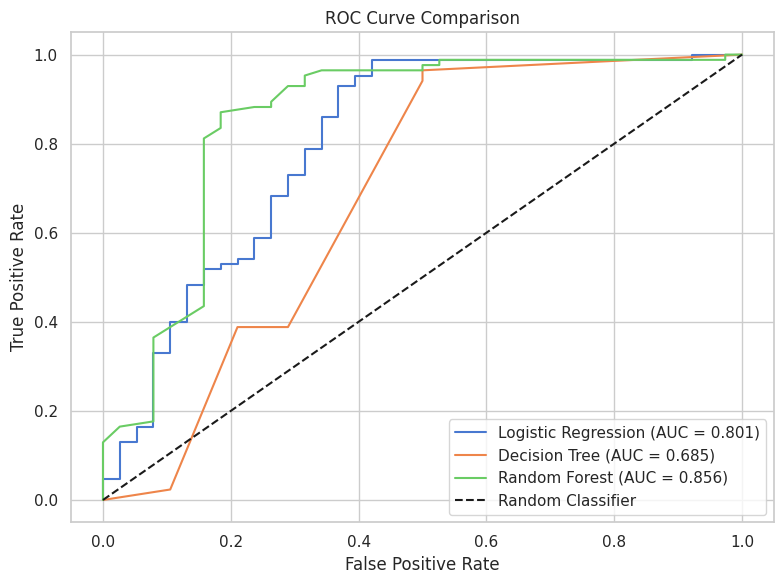

In [42]:
# ── ROC Curves ───────────────────────────────────────────────────────────────
plt.figure(figsize=(8, 6))

for name, res in results.items():
    clf = res['Model']
    if hasattr(clf, 'predict_proba'):
        proba = clf.predict_proba(X_test_sc)[:, 1]
    else:
        proba = clf.decision_function(X_test_sc)
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.tight_layout()
plt.show()


In [43]:
# ── Best Model – Detailed Report ──────────────────────────────────────────────
best_name = max(results, key=lambda k: results[k]['Test Accuracy'])
best_res  = results[best_name]

print("=" * 55)
print(f"BEST MODEL: {best_name}")
print("=" * 55)
print(classification_report(y_test, best_res['Predictions'],
                             target_names=['Not Approved', 'Approved']))


BEST MODEL: Logistic Regression
              precision    recall  f1-score   support

Not Approved       0.96      0.58      0.72        38
    Approved       0.84      0.99      0.91        85

    accuracy                           0.86       123
   macro avg       0.90      0.78      0.81       123
weighted avg       0.88      0.86      0.85       123



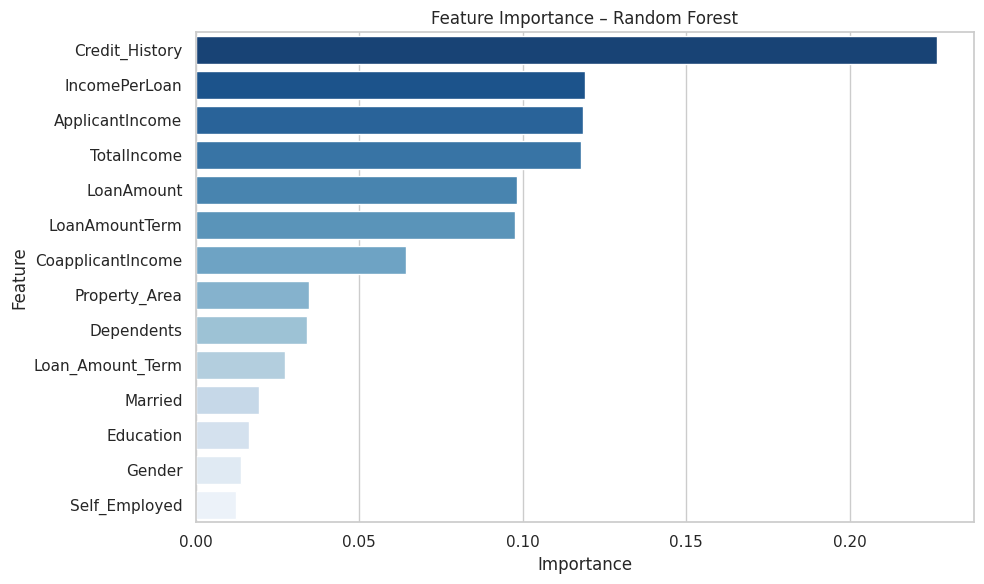


✅ Project 3 – Loan Eligibility Prediction Complete!


In [44]:
# ── Feature Importance (Random Forest) ───────────────────────────────────────
rf_model = results['Random Forest']['Model']
feat_imp  = pd.DataFrame({
    'Feature'   : X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp, x='Importance', y='Feature', palette='Blues_r')
plt.title("Feature Importance – Random Forest")
plt.tight_layout()
plt.show()

print("\n✅ Project 3 – Loan Eligibility Prediction Complete!")
